<a href="https://colab.research.google.com/github/challasreeja87-afk/Machine-Learning/blob/main/MLexp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [3]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset (2).csv


In [4]:
df = pd.read_csv('placement_predict_50k Dataset.csv')

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 32)
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             4

In [5]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully.")
print(df.isnull().sum())

Missing values handled successfully.
StudentID             0
Gender                0
City                  0
CollegeTier           0
Stream                0
Specialisation        0
Hostel                0
HistoryOfBacklogs     0
SGPA_Sem1             0
SGPA_Sem2             0
SGPA_Sem3             0
SGPA_Sem4             0
SGPA_Sem5             0
SGPA_Sem6             0
SGPA_Sem7             0
SGPA_Sem8             0
CGPA                  0
AttendancePercent     0
Internships           0
Projects              0
Workshops             0
Certifications        0
Publications          0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
ExtraCurricular       0
CGPA_Tier             0
PlacementStatus       0
IsAnomaly             0
Salary Package        0
dtype: int64


In [6]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Gender',
        'City',
        'CollegeTier',
        'Stream',
        'Specialisation',
        'Hostel',
        'HistoryOfBacklogs',
        'ExtraCurricular'
    ],
    drop_first=True
)

print("Categorical encoding completed.")
print(df_encoded.head())

Categorical encoding completed.
   StudentID  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  SGPA_Sem4  SGPA_Sem5  \
0          1       6.02       6.54       6.52       6.00       6.47   
1          2       5.84       5.12       5.34       5.18       5.03   
2          3       4.91       5.29       5.49       5.73       5.33   
3          4       7.67       8.03       8.08       7.64       6.86   
4          5       8.14       8.97       8.36       8.55       8.55   

   SGPA_Sem6  SGPA_Sem7  SGPA_Sem8  CGPA  ...  Stream_ECE  Stream_EE  \
0       5.91       6.49       5.50  6.29  ...        True      False   
1       4.93       5.40       5.13  5.23  ...        True      False   
2       5.88       5.82       5.67  5.52  ...       False      False   
3       7.10       7.56       7.39  7.51  ...       False      False   
4       8.38       9.10       8.86  8.65  ...       False      False   

   Stream_IT  Stream_Mechanical  Specialisation_DataScience  \
0      False              False              

In [7]:
X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 46)
y shape: (50000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 46)
Testing data: (10000, 46)


In [9]:
# Check which columns still contain text values
print("Columns with text data:")

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        print(col)

Columns with text data:
CGPA_Tier


In [10]:
# Encode any remaining categorical/text columns
df_encoded = pd.get_dummies(
    df_encoded,
    drop_first=True
)

print("All categorical columns encoded.")
print("Remaining object columns:")

print(df_encoded.select_dtypes(include=['object']).columns.tolist())

All categorical columns encoded.
Remaining object columns:
[]


In [11]:
X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 47)
y shape: (50000,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 47)
Testing data: (10000, 47)


In [13]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [14]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3422
           1       1.00      1.00      1.00      6578

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



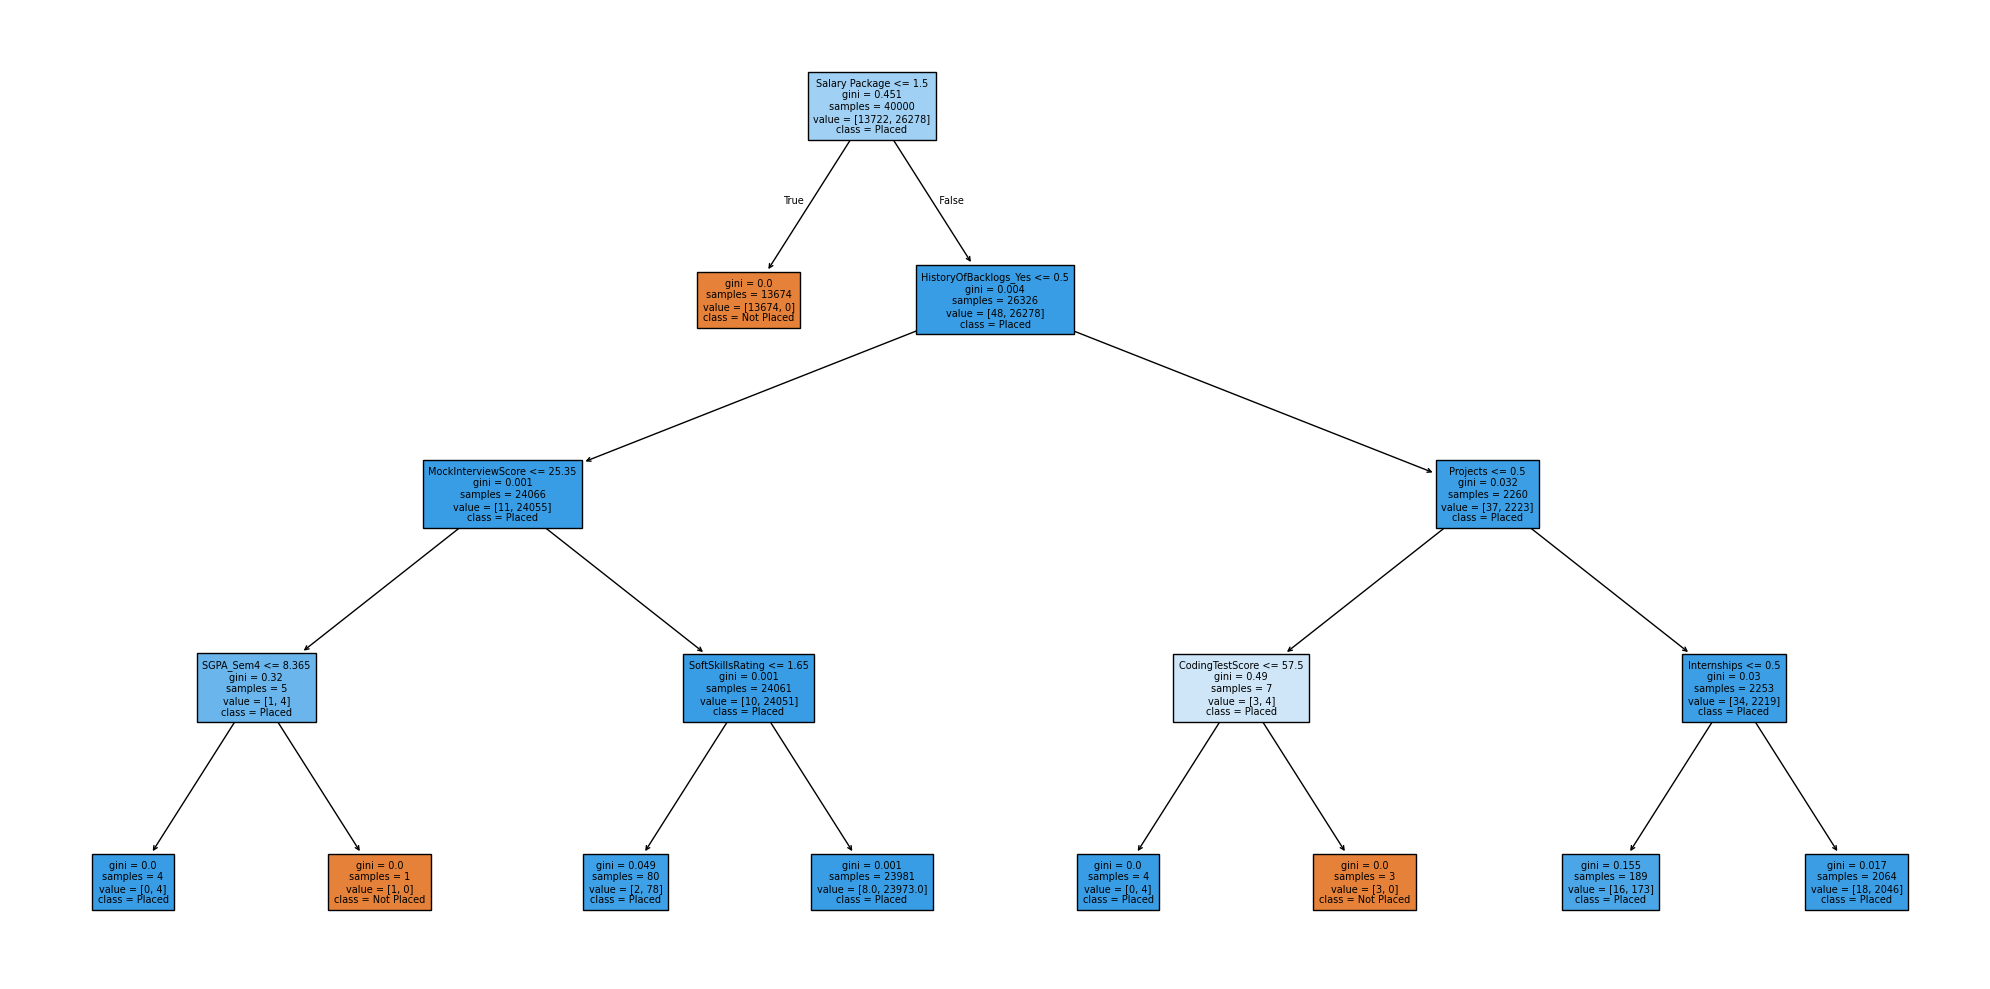

In [15]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()
plt.show()

Saved tree image.


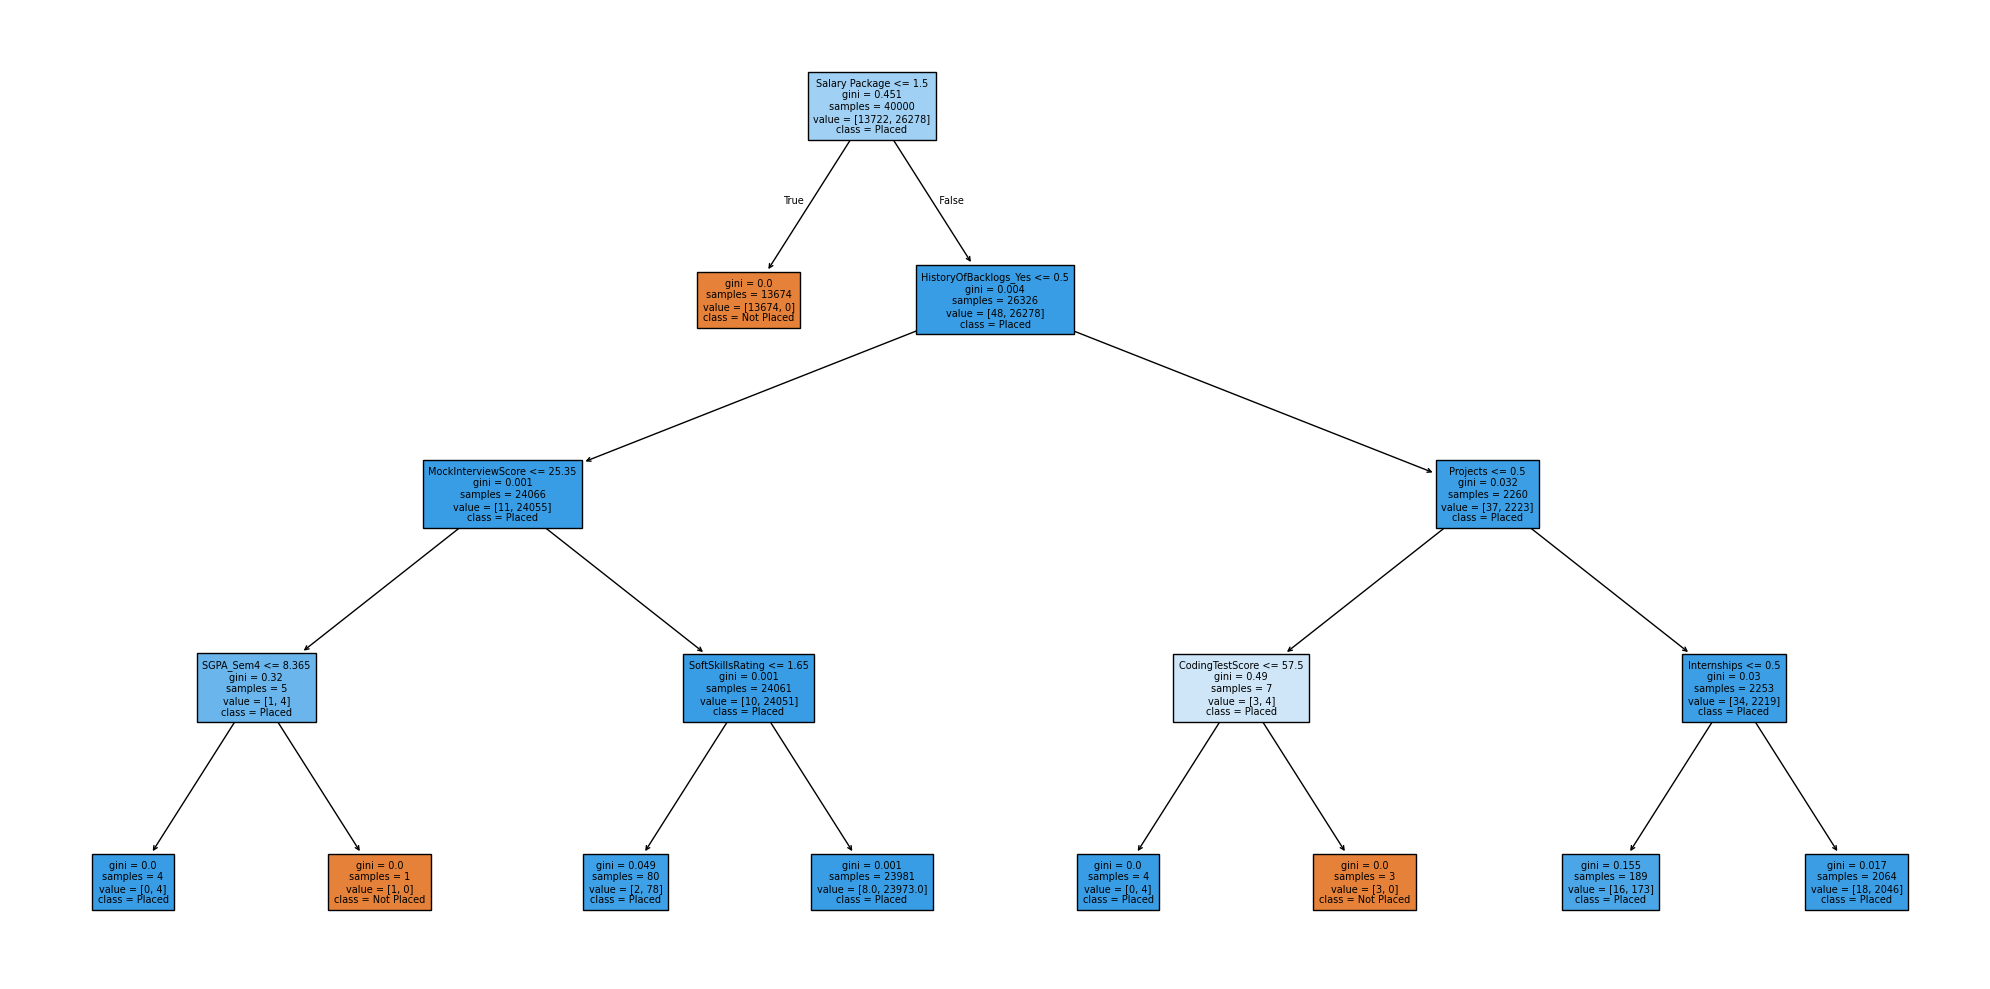

In [16]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)

print("Saved tree image.")

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
RANDOM_STATE = 42

rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [20]:
y_pred_rf = rf.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [21]:
test_accuracy = accuracy_score(y_test, y_pred_rf)

print("OOB Score:", round(rf.oob_score_, 4))
print("Test Accuracy:", round(test_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

OOB Score: 0.9988
Test Accuracy: 0.998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3422
           1       1.00      1.00      1.00      6578

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [22]:
print("Feature Importances:")

for name, importance in sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"{name}: {importance:.4f}")

Feature Importances:
Salary Package: 0.3604
SGPA_Sem8: 0.0788
SGPA_Sem7: 0.0645
CGPA_Tier_Low: 0.0608
CGPA: 0.0488
CodingTestScore: 0.0411
SGPA_Sem4: 0.0388
SGPA_Sem2: 0.0362
SGPA_Sem6: 0.0335
SoftSkillsRating: 0.0315
MockInterviewScore: 0.0298
SGPA_Sem5: 0.0281
Projects: 0.0242
SGPA_Sem3: 0.0211
SGPA_Sem1: 0.0175
AptitudeTestScore: 0.0166
AttendancePercent: 0.0154
Certifications: 0.0118
Internships: 0.0114
HistoryOfBacklogs_Yes: 0.0092
Workshops: 0.0042
CollegeTier_Tier3: 0.0032
StudentID: 0.0028
Publications: 0.0018
CGPA_Tier_Mid: 0.0011
IsAnomaly: 0.0006
ExtraCurricular_1: 0.0005
CollegeTier_Tier2: 0.0005
Hostel_Yes: 0.0004
Specialisation_Embedded: 0.0004
Gender_Male: 0.0004
City_Hyderabad: 0.0004
Stream_ECE: 0.0004
Specialisation_Networking: 0.0004
Stream_Mechanical: 0.0004
Specialisation_DataScience: 0.0003
City_Bangalore: 0.0003
City_Chennai: 0.0003
City_Mumbai: 0.0003
City_Delhi: 0.0003
Stream_IT: 0.0003
Stream_EE: 0.0003
City_Pune: 0.0003
Stream_Civil: 0.0003
City_Kolkata: 0.00